# FR / NFR 분류기 — ModernBERT vs DeBERTa-v3 vs BERT-base 벤치마크 (3-seed + latency)

`bert-base-uncased`(2018)를 대체할 최신 인코더를, **기존 baseline 포함 3자**로 **동일 조건**에서 비교합니다.

- **모델**: `answerdotai/ModernBERT-base` vs `microsoft/deberta-v3-base` vs `bert-base-uncased`(baseline)
- **공정성**: 데이터 split 고정(같은 val셋) · 동일 하이퍼파라미터 · 동일 class weight
- **통계적 엄밀성**: 각 모델을 **3개 seed**로 반복 학습 → **mean ± std** 집계
  - 단일 run의 0.008 macro-F1 격차는 노이즈이므로, 반복으로 실제 구분 가능 여부를 확인
  - split은 고정하고 **학습 seed**(head 초기화·셔플·dropout)만 변동시켜 학습 변동성을 측정
- **평가지표**: accuracy + **macro-F1** + per-class F1 (불균형 반영)
- **배포 관점**: 모델별 **추론 latency**(bs=1 p50/p95) + **throughput**(bs=32) + 파라미터 수
- **불균형 대응**: FR 3964 / NFR 2153 → class weight


## 1. 환경 설정
ModernBERT는 `transformers>=4.48`, DeBERTa-v3는 `sentencepiece`가 필요합니다. 설치 후 런타임 재시작 권장.

In [13]:
!pip install -q -U "transformers>=4.48" datasets accelerate evaluate scikit-learn openpyxl sentencepiece

## 2. 설정 및 데이터 로드
Split은 `SPLIT_SEED`로 **한 번만** 만들어 모든 모델·모든 seed가 **동일한 train/val**을 쓰도록 고정합니다.

In [14]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset

# ================= 설정 구역 =================
FILE_PATH  = "FR_NFR_Dataset.xlsx"
TEXT_COL   = "Requirement Text"
LABEL_COL  = "Type"
MAX_LENGTH = 128
SPLIT_SEED = 42            # 데이터 분할 고정 (val셋 불변)
SEEDS      = [42, 1, 2]    # 학습 반복 seed (3-seed)
USE_CLASS_WEIGHTS = True   # 불균형 대응 (NFR recall 개선)

MODELS = {
    "ModernBERT-base": "answerdotai/ModernBERT-base",
    "DeBERTa-v3-base": "microsoft/deberta-v3-base",
    "BERT-base (2018)": "bert-base-uncased",   # 기존 baseline — 동일 조건 재측정
}
# =============================================

df = pd.read_excel(FILE_PATH)
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

label_mapping = {"NFR": 0, "FR": 1}   # 고정 매핑 (재현성)
assert set(df[LABEL_COL].unique()) <= set(label_mapping), df[LABEL_COL].unique()
df[LABEL_COL] = df[LABEL_COL].map(label_mapping)
id2label = {v: k for k, v in label_mapping.items()}
label2id = label_mapping
df = df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=SPLIT_SEED, stratify=df["label"]
)
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset   = Dataset.from_pandas(val_df,   preserve_index=False)
print(f"train {len(train_df)} / val {len(val_df)}")
print("train label dist:", train_df["label"].value_counts().to_dict(), "(0=NFR, 1=FR)")

counts = train_df["label"].value_counts().sort_index().values
class_weights = torch.tensor((counts.sum() / (len(counts) * counts)), dtype=torch.float)
print("class weights [NFR, FR]:", class_weights.tolist())

train 4893 / val 1224
train label dist: {1: 3171, 0: 1722} (0=NFR, 1=FR)
class weights [NFR, FR]: [1.4207316637039185, 0.7715231776237488]


## 3. 평가지표 · 가중치 Trainer · 학습 함수 (seed 파라미터)
`train_and_eval(name, ckpt, seed)`: 한 (모델, seed)를 학습하고 지표를 반환한 뒤, **GPU 메모리를 해제**합니다(9회 반복 대비 OOM 방지).

In [15]:
import gc, evaluate
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed,
)
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_NFR":      f1_score(labels, preds, average=None, labels=[0])[0],
        "f1_FR":       f1_score(labels, preds, average=None, labels=[1])[0],
    }

class WeightedTrainer(Trainer):
    """class weight를 반영한 CrossEntropy loss."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        w = self._class_weights.to(outputs.logits.device) if self._class_weights is not None else None
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=w)
        return (loss, outputs) if return_outputs else loss

def train_and_eval(name, ckpt, seed):
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(ckpt)
    def tok(ex): return tokenizer(ex["text"], truncation=True, max_length=MAX_LENGTH)
    tr = train_dataset.map(tok, batched=True, remove_columns=["text"])
    va = val_dataset.map(tok,   batched=True, remove_columns=["text"])

    model = AutoModelForSequenceClassification.from_pretrained(
        ckpt, num_labels=2, id2label=id2label, label2id=label2id
    )
    # DeBERTa-v3 등 일부 체크포인트는 fp16 dtype으로 로드됨 → fp16 AMP 학습 시
    # "Attempting to unscale FP16 gradients" 발생. 마스터 가중치를 fp32로 강제.
    model = model.float()

    args = TrainingArguments(
        output_dir=f"./out_{name}_{seed}",
        eval_strategy="epoch", save_strategy="no",   # 반복 실험이라 체크포인트 저장 생략
        learning_rate=2e-5,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        num_train_epochs=3, weight_decay=0.01, warmup_ratio=0.1,
        logging_steps=100, seed=seed, report_to="none",
        fp16=torch.cuda.is_available(),
    )
    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=tr, eval_dataset=va,
        processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=class_weights if USE_CLASS_WEIGHTS else None,
    )
    trainer.train()
    m = trainer.evaluate()
    out = {k.replace("eval_", ""): v for k, v in m.items()
           if k in ("eval_accuracy","eval_f1_macro","eval_f1_weighted","eval_f1_NFR","eval_f1_FR","eval_loss")}

    # GPU 메모리 해제
    del trainer, model, tr, va
    gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()
    return out

## 4. 3-seed 벤치마크 실행
3 모델 × 3 seed = **9회 학습** (Colab T4 기준 약 30~45분). 진행 상황이 줄 단위로 출력됩니다.

In [16]:
runs = []
for name, ckpt in MODELS.items():
    for seed in SEEDS:
        m = train_and_eval(name, ckpt, seed)
        runs.append({"model": name, "seed": seed, **m})
        print(f"[{name:18s} seed={seed}] "
              f"acc={m['accuracy']:.4f}  macroF1={m['f1_macro']:.4f}  "
              f"NFR={m['f1_NFR']:.4f}  FR={m['f1_FR']:.4f}")

runs_df = pd.DataFrame(runs)
print("\n=== 개별 run ===")
print(runs_df.to_string(index=False))

Map:   0%|          | 0/4893 [00:00<?, ? examples/s]

Map:   0%|          | 0/1224 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Nfr,F1 Fr
1,0.369607,0.312636,0.861928,0.853535,0.863905,0.818475,0.888596
2,0.192816,0.361222,0.881536,0.872311,0.882461,0.837989,0.906632
3,0.085719,0.454939,0.884804,0.874482,0.885127,0.838488,0.910476


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Nfr,F1 Fr
1,0.362018,0.328670,0.868464,0.859007,0.869807,0.822492,0.895522
2,0.258373,0.332926,0.877451,0.869619,0.879070,0.837662,0.901575
3,0.169836,0.375953,0.897059,0.887662,0.897271,0.855172,0.920152


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted,F1 Nfr,F1 Fr
0.169836,0.375953,3,0.897059,0.887662,0.897271,0.855172,0.920152


[BERT-base (2018)   seed=2] acc=0.8971  macroF1=0.8877  NFR=0.8552  FR=0.9202

=== 개별 run ===
           model  seed     loss  accuracy  f1_macro  f1_weighted   f1_NFR    f1_FR
 ModernBERT-base    42 0.454939  0.884804  0.874482     0.885127 0.838488 0.910476
 ModernBERT-base     1 0.447261  0.890523  0.880895     0.890910 0.847032 0.914758
 ModernBERT-base     2 0.450606  0.898693  0.889445     0.898902 0.857471 0.921420
 DeBERTa-v3-base    42 0.356653  0.888072  0.878773     0.888703 0.845198 0.912348
 DeBERTa-v3-base     1 0.368671  0.891340  0.882080     0.891853 0.849035 0.915124
 DeBERTa-v3-base     2 0.369654  0.893791  0.884682     0.894267 0.852273 0.917092
BERT-base (2018)    42 0.363681  0.890523  0.882811     0.891702 0.852747 0.912874
BERT-base (2018)     1 0.336937  0.892974  0.884530     0.893765 0.853303 0.915756
BERT-base (2018)     2 0.375953  0.897059  0.887662     0.897271 0.855172 0.920152


## 5. mean ± std 집계 (통계적 비교)

In [17]:
def fmt(m, s): return f"{m:.4f} ± {s:.4f}"

agg = runs_df.groupby("model").agg(["mean", "std"])
metrics_cols = ["accuracy", "f1_macro", "f1_weighted", "f1_NFR", "f1_FR"]

table = pd.DataFrame({
    col: [fmt(agg.loc[mdl, (col, "mean")], agg.loc[mdl, (col, "std")]) for mdl in agg.index]
    for col in metrics_cols
}, index=agg.index)
table = table.reindex(agg[("f1_macro","mean")].sort_values(ascending=False).index)
print(f"=== {len(SEEDS)}-seed 집계 (mean ± std, f1_macro 평균 기준 정렬) ===")
print(table.to_string())

# 최고 평균 macro-F1 & 구분 가능 여부(간이 판정: 평균차 vs 합산 std)
order = agg[("f1_macro","mean")].sort_values(ascending=False)
best_name = order.index[0]
top_mean, top_std = agg.loc[best_name, ("f1_macro","mean")], agg.loc[best_name, ("f1_macro","std")]
print(f"\n최고 평균 macro-F1: {best_name} ({top_mean:.4f})")
for mdl in order.index[1:]:
    mmean, mstd = agg.loc[mdl, ("f1_macro","mean")], agg.loc[mdl, ("f1_macro","std")]
    gap = top_mean - mmean
    overlap = gap < (top_std + mstd)   # 오차막대 겹침 → 사실상 동점
    print(f"  vs {mdl:18s}: Δ={gap:.4f}  {'≈ 동점(오차범위 겹침)' if overlap else '구분됨'}")

=== 3-seed 집계 (mean ± std, f1_macro 평균 기준 정렬) ===
                         accuracy         f1_macro      f1_weighted           f1_NFR            f1_FR
model                                                                                                
BERT-base (2018)  0.8935 ± 0.0033  0.8850 ± 0.0025  0.8942 ± 0.0028  0.8537 ± 0.0013  0.9163 ± 0.0037
DeBERTa-v3-base   0.8911 ± 0.0029  0.8818 ± 0.0030  0.8916 ± 0.0028  0.8488 ± 0.0035  0.9149 ± 0.0024
ModernBERT-base   0.8913 ± 0.0070  0.8816 ± 0.0075  0.8916 ± 0.0069  0.8477 ± 0.0095  0.9156 ± 0.0055

최고 평균 macro-F1: BERT-base (2018) (0.8850)
  vs DeBERTa-v3-base   : Δ=0.0032  ≈ 동점(오차범위 겹침)
  vs ModernBERT-base   : Δ=0.0034  ≈ 동점(오차범위 겹침)


## 6. macro-F1 mean±std 시각화

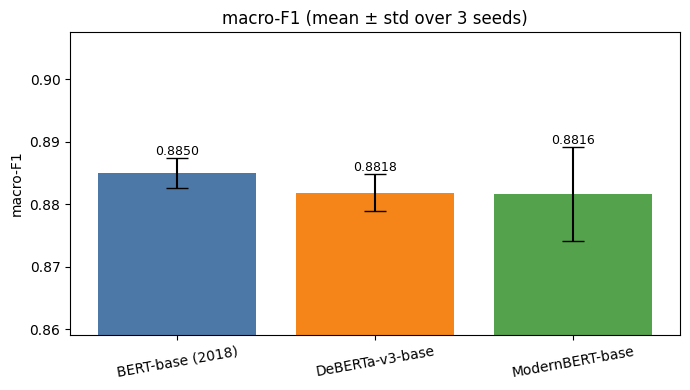

In [18]:
import matplotlib.pyplot as plt

mdls = list(order.index)
means = [agg.loc[m, ("f1_macro","mean")] for m in mdls]
stds  = [agg.loc[m, ("f1_macro","std")]  for m in mdls]

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(range(len(mdls)), means, yerr=stds, capsize=8, color=["#4C78A8","#F58518","#54A24B"])
ax.set_xticks(range(len(mdls))); ax.set_xticklabels(mdls, rotation=10)
ax.set_ylabel("macro-F1"); ax.set_ylim(min(means)-max(stds)*3, max(means)+max(stds)*3)
ax.set_title(f"macro-F1 (mean ± std over {len(SEEDS)} seeds)")
for i,(mn,sd) in enumerate(zip(means,stds)):
    ax.text(i, mn+sd, f"{mn:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 7. 추론 Latency / Throughput 측정
학습 정확도가 동점일 때 **배포 효율**이 실질적 선택 기준이 됩니다.
- **bs=1 latency** (p50/p95): 단건 요청 지연 (FastAPI 실서빙 시나리오)
- **throughput** (bs=32): 배치 처리량
- 측정은 학습 가중치와 무관(구조/정밀도에만 의존)하므로 사전학습 가중치를 로드해 측정. fp32·eval·`no_grad`.

In [19]:
import time

LAT_POOL = [
    "The system shall allow users to search for products by name or keyword.",
    "The product page shall load within 3 seconds under normal network conditions.",
    "User passwords shall be stored using secure hashing algorithms.",
    "The system shall allow registered users to log in and log out.",
    "The website shall support Chrome, Firefox, Safari, and Edge browsers.",
    "The system shall send an order confirmation email after successful checkout.",
    "The system shall support concurrent access for at least 100 users simultaneously.",
    "The system shall display recommended items based on user preferences.",
]

@torch.no_grad()
def bench_latency(name, ckpt, n_warmup=15, n_iter=120):
    tok = AutoTokenizer.from_pretrained(ckpt)
    model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=2).float().to(device).eval()
    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    def one(text):
        enc = tok(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = torch.softmax(model(**enc).logits, dim=-1)
        if device.type == "cuda": torch.cuda.synchronize()
        return (time.perf_counter() - t0) * 1000.0

    for i in range(n_warmup): one(LAT_POOL[i % len(LAT_POOL)])
    lat = sorted(one(LAT_POOL[i % len(LAT_POOL)]) for i in range(n_iter))
    p50, p95, mean = lat[int(.50*n_iter)], lat[int(.95*n_iter)], sum(lat)/len(lat)

    # throughput (bs=32)
    batch = (LAT_POOL * 4)[:32]
    enc = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to(device)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(20): _ = model(**enc).logits
    if device.type == "cuda": torch.cuda.synchronize()
    thr = (20 * 32) / (time.perf_counter() - t0)

    del model; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()
    return {"model": name, "params(M)": round(n_params,1),
            "p50_ms(bs1)": round(p50,2), "p95_ms(bs1)": round(p95,2),
            "mean_ms(bs1)": round(mean,2), "throughput(sent/s,bs32)": round(thr,1)}

lat_rows = [bench_latency(name, ckpt) for name, ckpt in MODELS.items()]
lat_df = pd.DataFrame(lat_rows).sort_values("p50_ms(bs1)").reset_index(drop=True)
print(f"=== 추론 성능 (device={device.type}, fp32) ===")
print(lat_df.to_string(index=False))

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== 추론 성능 (device=cuda, fp32) ===
           model  params(M)  p50_ms(bs1)  p95_ms(bs1)  mean_ms(bs1)  throughput(sent/s,bs32)
BERT-base (2018)      109.5        14.93        25.68         16.52                    830.3
 ModernBERT-base      149.6        34.90        80.03         40.64                    693.0
 DeBERTa-v3-base      184.4        39.24        62.61         41.28                    394.5


## 8. 최종 요약 (정확도 + 효율 통합)

In [20]:
summary = table.copy()
summary["macro-F1(mean)"] = [f"{agg.loc[m, ('f1_macro','mean')]:.4f}" for m in summary.index]
lat_idx = lat_df.set_index("model")
summary["p50_ms(bs1)"]  = [lat_idx.loc[m, "p50_ms(bs1)"] for m in summary.index]
summary["params(M)"]    = [lat_idx.loc[m, "params(M)"] for m in summary.index]
print("=== 통합 요약 ===")
print(summary[["macro-F1(mean)","f1_macro","p50_ms(bs1)","params(M)"]].to_string())
print("\n해석 가이드:")
print("- macro-F1이 오차범위 안에서 겹치면 정확도는 '동점' → latency/params가 낮은 모델 선택 근거가 됨")
print("- 셀 5의 '≈ 동점/구분됨' 판정과 함께 종합 판단")

=== 통합 요약 ===
                 macro-F1(mean)         f1_macro  p50_ms(bs1)  params(M)
model                                                                   
BERT-base (2018)         0.8850  0.8850 ± 0.0025        14.93      109.5
DeBERTa-v3-base          0.8818  0.8818 ± 0.0030        39.24      184.4
ModernBERT-base          0.8816  0.8816 ± 0.0075        34.90      149.6

해석 가이드:
- macro-F1이 오차범위 안에서 겹치면 정확도는 '동점' → latency/params가 낮은 모델 선택 근거가 됨
- 셀 5의 '≈ 동점/구분됨' 판정과 함께 종합 판단


## 9. 승자 모델 재학습·저장 및 실사용 테스트
집계에서 최고 평균 macro-F1 모델을 seed=42로 한 번 더 학습해 저장합니다.

In [21]:
win_ckpt = MODELS[best_name]
print(f"승자 재학습: {best_name} ({win_ckpt})")
set_seed(42)
win_tok = AutoTokenizer.from_pretrained(win_ckpt)
def _tok(ex): return win_tok(ex["text"], truncation=True, max_length=MAX_LENGTH)
_tr = train_dataset.map(_tok, batched=True, remove_columns=["text"])
win_model = AutoModelForSequenceClassification.from_pretrained(
    win_ckpt, num_labels=2, id2label=id2label, label2id=label2id).float()
_args = TrainingArguments(output_dir="./out_winner", eval_strategy="no", save_strategy="no",
    learning_rate=2e-5, per_device_train_batch_size=16, num_train_epochs=3,
    weight_decay=0.01, warmup_ratio=0.1, logging_steps=100, seed=42,
    report_to="none", fp16=torch.cuda.is_available())
win_trainer = WeightedTrainer(model=win_model, args=_args, train_dataset=_tr,
    processing_class=win_tok, data_collator=DataCollatorWithPadding(win_tok),
    class_weights=class_weights if USE_CLASS_WEIGHTS else None)
win_trainer.train()

# (선택) 구글 드라이브 저장:
# from google.colab import drive; drive.mount("/content/drive")
# save_path = f"/content/drive/MyDrive/fr_nfr_{best_name}"
save_path = f"./fr_nfr_{best_name}".replace(" ", "_")
win_trainer.save_model(save_path); win_tok.save_pretrained(save_path)
print("저장:", save_path)

@torch.no_grad()
def predict(text):
    win_model.eval()
    enc = win_tok(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(win_model.device)
    probs = torch.softmax(win_model(**enc).logits, dim=-1)[0]
    c = int(probs.argmax()); return id2label[c], float(probs[c])

for s in [
    "The system shall allow administrators to revoke user access permissions immediately.",
    "The system must be operational 99.9% of the time during business hours.",
    "The product page shall load within 3 seconds under normal network conditions.",
    "The system shall allow users to add toys to a wishlist.",
]:
    label, p = predict(s); print(f"[{label}] ({p:.3f})  {s}")

승자 재학습: BERT-base (2018) (bert-base-uncased)


Map:   0%|          | 0/4893 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Step,Training Loss
100,0.598757
200,0.394314
300,0.374538
400,0.310053
500,0.299523
600,0.264042
700,0.219971
800,0.167111
900,0.203481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

저장: ./fr_nfr_BERT-base_(2018)
[FR] (0.939)  The system shall allow administrators to revoke user access permissions immediately.
[NFR] (0.993)  The system must be operational 99.9% of the time during business hours.
[NFR] (0.993)  The product page shall load within 3 seconds under normal network conditions.
[FR] (0.993)  The system shall allow users to add toys to a wishlist.
